# Clustering and Association Rule Mining Assignment

## Business Understanding

This task is split into two sub tasks:
- Finding optimal hub locations
- Finding interesting relationships between product groups.

First let's import the necessary libraries.

In [82]:
import time
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from scipy.cluster.hierarchy import centroid
from sklearn.cluster import KMeans
from sklearn.cluster import AgglomerativeClustering
from mlxtend.frequent_patterns import apriori
from mlxtend.frequent_patterns import association_rules

## Data understanding

We have two datasets. 
- Drone_cust_locations - Contains the locations of customers. 
- Drone_prod_groups - Contains the sales data for products

Let's load the datasets.

In [83]:
drone_cust_locations_data = pd.read_csv('datasets/drone_cust_locations.csv', sep=';')
drone_prod_groups_data = pd.read_csv('datasets/drone_prod_groups.csv', sep=',')


Now we will take a look at the drone_cust_locations dataset.

In [84]:
drone_cust_locations_data.head()

,clientid,x,y
0,1,622.771572,164.857623
1,2,416.357298,630.193634
2,3,292.735020,567.333231
3,4,737.211288,166.225676
4,5,540.475375,682.912298


The dataset contains 3 columns:
- cust_id: Unique identifier for each customer
- x: x-coordinate of the customer's location when plotted on a 2D plane
- y: y-coordinate of the customer's location when plotted on a 2D plane


Next we will take a look at the drone_prod_groups dataset.

In [85]:
drone_prod_groups_data.head()

,ID,Prod1,Prod2,Prod3,Prod4,Prod5,Prod6,Prod7,Prod8,Prod9,...,Prod11,Prod12,Prod13,Prod14,Prod15,Prod16,Prod17,Prod18,Prod19,Prod20
0,1,0,0,0,0,0,0,0,0,1,...,0,0,0,0,1,0,0,0,0,1
1,2,0,1,0,0,0,0,0,0,1,...,0,0,0,0,1,1,1,1,1,1
2,3,0,0,0,0,0,0,1,0,0,...,0,0,0,0,0,0,0,0,1,1
3,4,1,0,0,1,0,0,0,0,0,...,1,0,0,0,0,0,0,0,1,1
4,5,0,0,0,0,0,0,0,0,1,...,0,0,0,0,1,0,0,0,1,1


The dataset contains 21 columns:
- ID - Transaction ID

Binary variables (Prod1 -> all the way to Prod20) indicating whether at least one product from a particular group was purchased in the transaction. A value (1) indicates that at least one product from the group was purchased, while a value (0) indicates that no products from the group were purchased. 



Now let's create a 2d scatter plot to visualize customer locations to help us understand this dataset better.

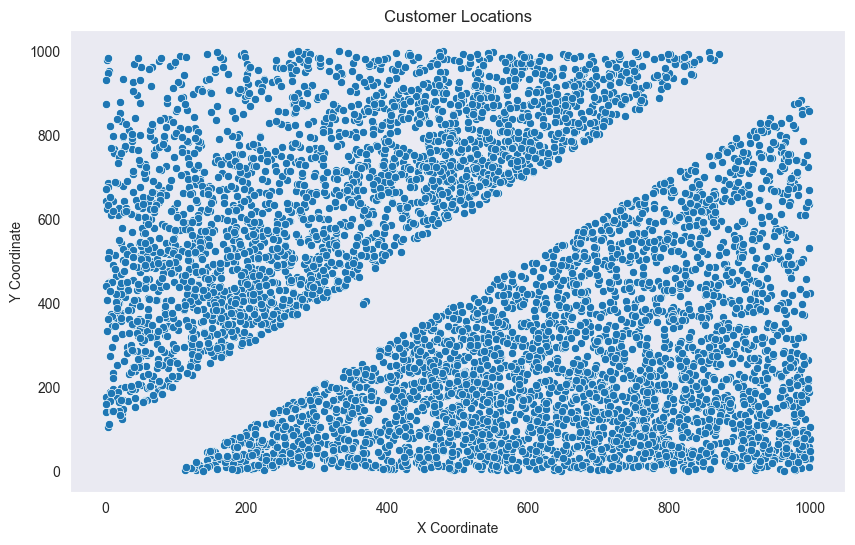

In [86]:
plt.figure(figsize=(10, 6))
sns.scatterplot(x='x', y='y', data=drone_cust_locations_data)
plt.title('Customer Locations')
plt.xlabel('X Coordinate')
plt.ylabel('Y Coordinate')
plt.grid()
plt.show()

Now that the datasets have been loaded and we have a basic understanding of them, it's time to prepare the data for modeling.

## Data preparation

Let's prepare the datasets by checking for missing values and duplicates.

In [87]:
# Check for missing values
print("Missing values in drone_cust_locations_data:")
print(drone_cust_locations_data.isnull().sum())
print("\nMissing values in drone_prod_groups_data:")
print(drone_prod_groups_data.isnull().sum())


Missing values in drone_cust_locations_data:
clientid    0
x           0
y           0
dtype: int64

Missing values in drone_prod_groups_data:
ID         0
Prod1      0
 Prod2     0
 Prod3     0
 Prod4     0
 Prod5     0
 Prod6     0
 Prod7     0
 Prod8     0
 Prod9     0
 Prod10    0
 Prod11    0
 Prod12    0
 Prod13    0
 Prod14    0
 Prod15    0
 Prod16    0
 Prod17    0
 Prod18    0
 Prod19    0
 Prod20    0
dtype: int64


## Modeling

We have two tasks:
- Finding optimal hub locations
- Finding interesting relationships between product groups.

#### Finding optimal hub locations

We will start by applying kMeans clustering algorithm to find the optimal hub locations. We will use x and y coordinates of the customers to cluster them into 3 clusters.

In [88]:
kmeans = KMeans(n_clusters=3, random_state=42)
drone_cust_locations_data['cluster'] = kmeans.fit_predict(drone_cust_locations_data[['x', 'y']])

Now we will visualize the clusters along with the depot locations.
- X marks the depot locations which are the centroids of the clusters.

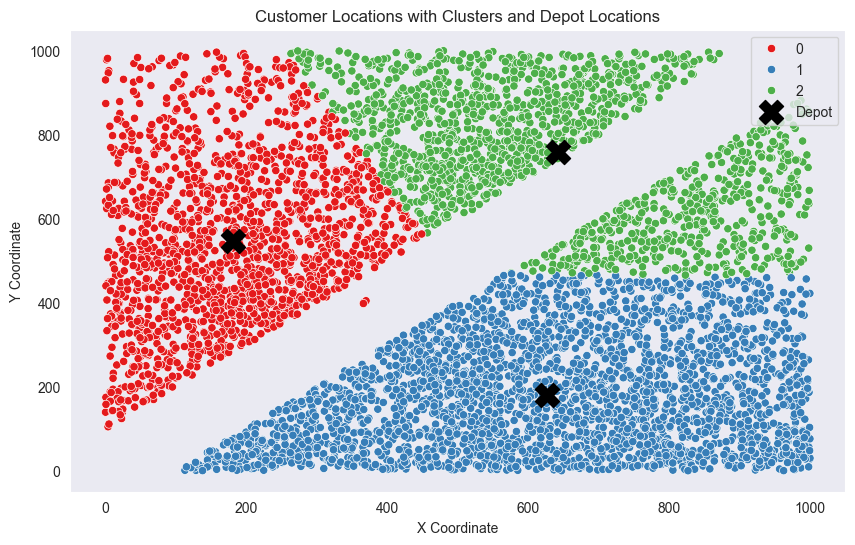

In [89]:
# Get centroid coordinates
centroids = kmeans.cluster_centers_

plt.figure(figsize=(10, 6))

# Plot customers colored by cluster
sns.scatterplot(
    x='x', 
    y='y', 
    hue='cluster', 
    data=drone_cust_locations_data, 
    palette='Set1'
)

plt.scatter(
    centroids[:, 0], 
    centroids[:, 1],
    s=300,              
    c='black',          
    marker='X',         
    label='Depot'
)

plt.title('Customer Locations with Clusters and Depot Locations')
plt.xlabel('X Coordinate')
plt.ylabel('Y Coordinate')
plt.legend()
plt.grid()

plt.show()

Now that the first task of the modeling is done, let's move on to the second task which is finding interesting relationships between product groups. 

#### Finding interesting relationships between product groups
To achieve this, we will apply rule mining using the Apriori algorithm and find the assocation rules between the product groups. Then we will visualize them.

                              antecedents                    consequents  \
0                     frozenset({ Prod5})           frozenset({ Prod12})   
1                    frozenset({ Prod15})            frozenset({ Prod9})   
2                     frozenset({ Prod9})           frozenset({ Prod15})   
3                    frozenset({ Prod20})           frozenset({ Prod19})   
4                    frozenset({ Prod19})           frozenset({ Prod20})   
..                                    ...                            ...   
72  frozenset({ Prod20,  Prod9,  Prod15})           frozenset({ Prod19})   
73  frozenset({ Prod15,  Prod19,  Prod9})           frozenset({ Prod20})   
74          frozenset({ Prod20,  Prod15})   frozenset({ Prod19,  Prod9})   
75           frozenset({ Prod20,  Prod9})  frozenset({ Prod15,  Prod19})   
76          frozenset({ Prod15,  Prod19})   frozenset({ Prod20,  Prod9})   

    support  confidence       lift  
0   0.06683    0.638971   4.000822  
1   0.11145  

,antecedents,consequents,support,confidence,lift
0,"frozenset({ Prod15, Prod19})","frozenset({ Prod20, Prod9})",0.01919,0.631042,17.166551
1,"frozenset({ Prod20, Prod9})","frozenset({ Prod15, Prod19})",0.01919,0.522035,17.166551
2,"frozenset({ Prod20, Prod15})","frozenset({ Prod19, Prod9})",0.01919,0.856314,17.139995
3,"frozenset({ Prod20, Prod5})","frozenset({ Prod12, Prod19})",0.01101,0.583157,15.025941
4,"frozenset({ Prod20, Prod9})",frozenset({ Prod15}),0.02119,0.576442,4.852204
5,"frozenset({ Prod9, Prod16})",frozenset({ Prod15}),0.01820,0.575949,4.848059
6,"frozenset({ Prod2, Prod9})",frozenset({ Prod15}),0.01843,0.574143,4.832856
7,"frozenset({ Prod20, Prod19, Prod9})",frozenset({ Prod15}),0.01919,0.573692,4.829058
8,"frozenset({ Prod19, Prod9})",frozenset({ Prod15}),0.02861,0.572658,4.820355
9,"frozenset({ Prod5, Prod9})",frozenset({ Prod15}),0.01409,0.572299,4.817331


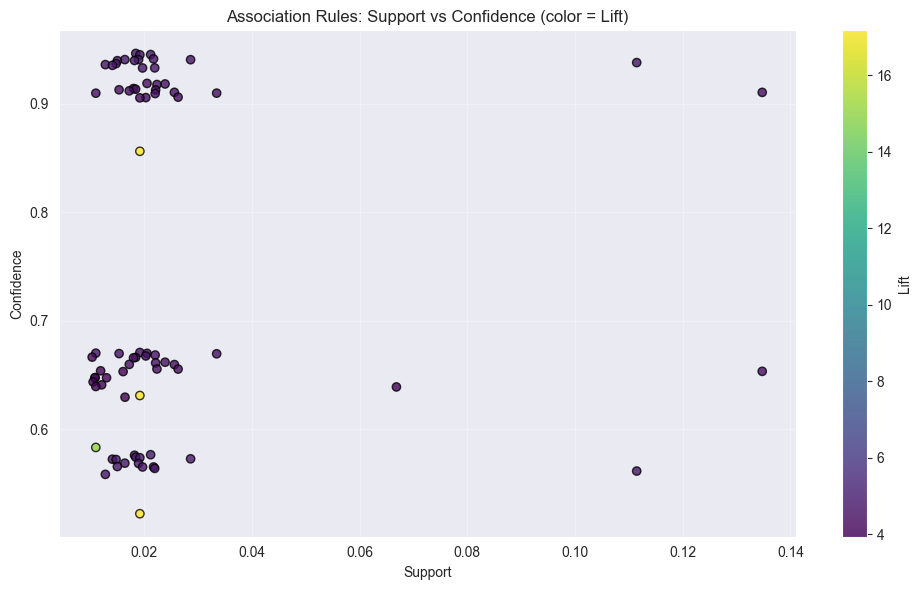

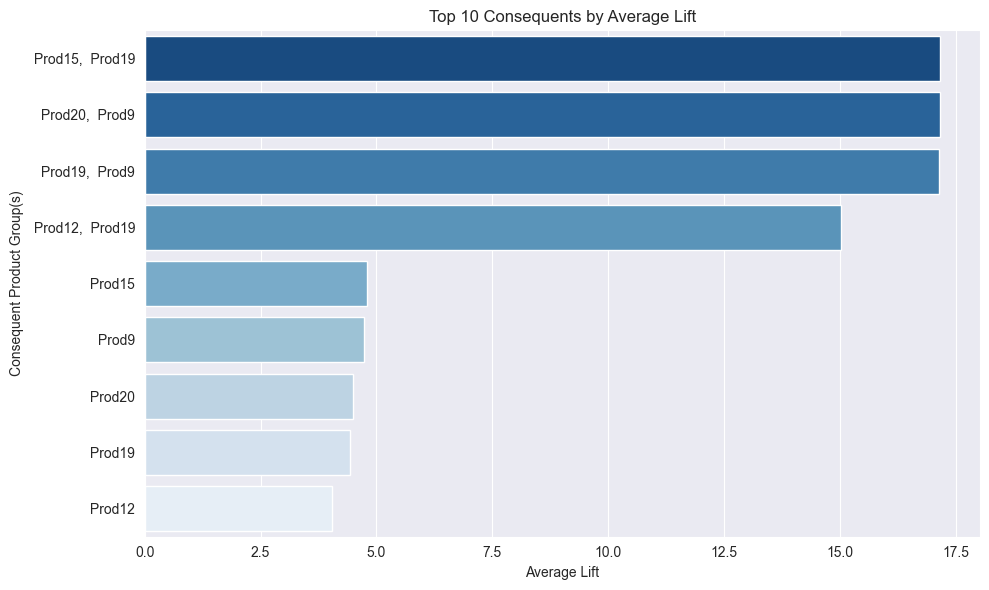

In [90]:
# association rule mining

# Drop the ID and convert 0/1 to bool for Apriori
prod_data_bool = drone_prod_groups_data.drop('ID', axis=1).astype(bool)

# Apply apriori algorithm to find frequent itemsets
frequent_itemsets = apriori(prod_data_bool, min_support=0.01, use_colnames=True)

# Generate association rules from the frequent itemsets
rules = association_rules(frequent_itemsets, metric="confidence", min_threshold=0.5)

# Display the generated rules
print(rules[['antecedents', 'consequents', 'support', 'confidence', 'lift']])#%%
# association rule mining

# Drop the ID and convert 0/1 to bool for Apriori
prod_data_bool = drone_prod_groups_data.drop('ID', axis=1).astype(bool)

# Apply apriori algorithm to find frequent itemsets
frequent_itemsets = apriori(prod_data_bool, min_support=0.01, use_colnames=True)

# Generate association rules from the frequent itemsets
rules = association_rules(frequent_itemsets, metric="confidence", min_threshold=0.5)

# Basic tidy table: sort by lift (most interesting first)
rules_sorted = rules.sort_values(by='lift', ascending=False).reset_index(drop=True)

display(
    rules_sorted[['antecedents', 'consequents', 'support', 'confidence', 'lift']].head(15)
)

# ---- Visualization 1: scatter of rules (support vs confidence, colored by lift) ----
plt.figure(figsize=(10, 6))
scatter = plt.scatter(
    rules_sorted['support'],
    rules_sorted['confidence'],
    c=rules_sorted['lift'],
    cmap='viridis',
    alpha=0.8,
    edgecolor='k'
)
cbar = plt.colorbar(scatter)
cbar.set_label('Lift')

plt.title('Association Rules: Support vs Confidence (color = Lift)')
plt.xlabel('Support')
plt.ylabel('Confidence')
plt.grid(alpha=0.3)
plt.tight_layout()
plt.show()

# ---- Visualization 2: barplot of top consequents by average lift ----
# Convert frozensets to strings for plotting
rules_sorted['antecedents_str'] = rules_sorted['antecedents'].apply(
    lambda x: ', '.join(sorted(list(x)))
)
rules_sorted['consequents_str'] = rules_sorted['consequents'].apply(
    lambda x: ', '.join(sorted(list(x)))
)

# Compute average lift per consequent
consequent_lift = (
    rules_sorted
    .groupby('consequents_str')['lift']
    .mean()
    .sort_values(ascending=False)
    .head(10)  # top 10 consequents
)

plt.figure(figsize=(10, 6))
sns.barplot(
    x=consequent_lift.values,
    y=consequent_lift.index,
    hue=consequent_lift.index,  # <- added
    dodge=False,                # <- added to keep bars aligned
    palette='Blues_r',
    legend=False,               # <- added to hide redundant legend
)
plt.title('Top 10 Consequents by Average Lift')
plt.xlabel('Average Lift')
plt.ylabel('Consequent Product Group(s)')
plt.tight_layout()
plt.show()


## Evaluation

## Deployment